# Projeto FIAP Fase 4

# Teste de Treinamento

In [156]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

In [157]:
conn = sqlite3.connect("./src/database/bronze.db")

In [158]:
df = pd.read_sql("SELECT * FROM stocks_raw", conn)

df["Date"] = pd.to_datetime(df["Date"])

df


,Date,Ticker,Close,High,Low,Open,Volume
0,2002-01-02,AAPL,0.349069,0.349069,0.328994,0.330342,529496800.0
1,2002-01-02,AMZN,0.548000,0.550000,0.524000,0.546500,130392000.0
2,2002-01-02,MSFT,20.429262,20.450593,19.963022,20.310417,48124000.0
3,2002-01-03,AAPL,0.353264,0.355811,0.341129,0.344574,612007200.0
4,2002-01-03,AMZN,0.595000,0.597000,0.552500,0.556500,217514000.0
...,...,...,...,...,...,...,...
27279,2026-04-17,AAPL,270.230011,272.299988,266.720001,266.959991,61436200.0
27280,2026-04-17,AMZN,250.559998,256.179993,250.110001,254.990005,52029300.0
27281,2026-04-17,GOOGL,341.679993,342.320007,336.239990,337.649994,25581900.0
27282,2026-04-17,META,688.549988,691.520020,675.130005,678.599976,16283500.0


In [159]:
list_tickers = list(df["Ticker"].unique())
list_tickers

['AAPL', 'AMZN', 'MSFT', 'GOOGL', 'META']

# Treinamento do modelo

In [160]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.tensorflow
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# =========================
# 1. PREPARAÇÃO DOS DADOS
# =========================

df_aapl = df[df["Ticker"] == "AAPL"].copy()
df_aapl = df_aapl.sort_values("Date").reset_index(drop=True)

# Features derivadas APENAS de dados passados (sem lookahead)
df_aapl["RETURN"] = df_aapl["Close"].pct_change()
df_aapl["RETURN_2"] = df_aapl["Close"].pct_change(2)
df_aapl["RETURN_5"] = df_aapl["Close"].pct_change(5)
df_aapl["LOG_RETURN"] = np.log(df_aapl["Close"] / df_aapl["Close"].shift(1))
df_aapl["HIGH_LOW_PCT"] = (df_aapl["High"] - df_aapl["Low"]) / df_aapl["Close"]
df_aapl["OPEN_CLOSE"] = (df_aapl["Close"] - df_aapl["Open"]) / df_aapl["Open"]
df_aapl["VOLATILITY_5"] = df_aapl["RETURN"].rolling(5).std()
df_aapl["VOLATILITY_20"] = df_aapl["RETURN"].rolling(20).std()
df_aapl["VOL_CHANGE"] = df_aapl["Volume"].pct_change()
df_aapl["MOMENTUM_5"] = df_aapl["RETURN"].rolling(5).sum()
df_aapl["MOMENTUM_10"] = df_aapl["RETURN"].rolling(10).sum()

# RSI corretamente calculado (usa só passado)
delta = df_aapl["Close"].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = -delta.clip(upper=0).rolling(14).mean()
df_aapl["RSI"] = 100 - (100 / (1 + gain / (loss + 1e-10)))

# MACD
df_aapl["MACD"] = (df_aapl["Close"].ewm(span=12).mean()
                 - df_aapl["Close"].ewm(span=26).mean())
df_aapl["MACD_SIGNAL"] = df_aapl["MACD"].ewm(span=9).mean()
df_aapl["MACD_HIST"]   = df_aapl["MACD"] - df_aapl["MACD_SIGNAL"]

df_aapl = df_aapl.dropna().reset_index(drop=True)

# TARGET: retorno do dia SEGUINTE (t+1)
df_aapl["TARGET"] = df_aapl["RETURN"].shift(-1)
df_aapl = df_aapl.dropna().reset_index(drop=True)

# Features — sem Close absoluto, sem MA longas (evita leak)
# Tudo em termos relativos/percentuais para ser estacionário
features = [
    "RETURN", "RETURN_2", "RETURN_5", "LOG_RETURN",
    "HIGH_LOW_PCT", "OPEN_CLOSE",
    "VOLATILITY_5", "VOLATILITY_20",
    "VOL_CHANGE", "MOMENTUM_5", "MOMENTUM_10",
    "RSI", "MACD_HIST",
]

print(f"Features: {len(features)} | Amostras: {len(df_aapl)}")

# =========================
# 2. SPLIT — sem normalização global (séries estacionárias não precisam)
# =========================

WINDOW_SIZE = 30   # reduzido: retornos têm memória curta
TARGET_COL  = "TARGET"

data   = df_aapl[features].values
target = df_aapl[TARGET_COL].values

split_idx = int(0.8 * len(data))

# =========================
# 3. NORMALIZAÇÃO POR JANELA (evita leak de escala)
# =========================

def create_sequences_window_norm(data, target, window_size=30):
    """
    Normaliza cada janela pelo seu próprio desvio padrão.
    Isso elimina o leak de escala e torna o modelo robusto
    a diferentes níveis de volatilidade.
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        window = data[i - window_size:i].copy()

        # Normaliza cada feature pela std da janela (z-score simplificado)
        std = window.std(axis=0)
        std[std < 1e-8] = 1.0   # evita divisão por zero
        window_norm = (window - window.mean(axis=0)) / std

        X.append(window_norm)
        y.append(target[i])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = create_sequences_window_norm(data, target, WINDOW_SIZE)

X_train, X_test = X_all[:split_idx - WINDOW_SIZE], X_all[split_idx - WINDOW_SIZE:]
y_train, y_test = y_all[:split_idx - WINDOW_SIZE], y_all[split_idx - WINDOW_SIZE:]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Retorno médio treino : {y_train.mean()*100:.4f}% ± {y_train.std()*100:.4f}%")
print(f"Retorno médio teste  : {y_test.mean()*100:.4f}% ± {y_test.std()*100:.4f}%")

# =========================
# 4. MODELO — Bidirectional LSTM + regularização
# =========================

def build_model(input_shape):
    model = Sequential([
        # Bidirecional captura padrões em ambas as direções temporais
        Bidirectional(
            LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
            input_shape=input_shape
        ),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(LSTM(32, return_sequences=False, kernel_regularizer=l2(1e-4))),
        BatchNormalization(),
        Dropout(0.3),

        Dense(16, activation="relu", kernel_regularizer=l2(1e-4)),
        Dropout(0.2),
        Dense(1),  # regressão linear — retorno previsto
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),   # LR menor para convergência mais suave
        loss="huber",    # Huber é mais robusto a outliers que MSE para retornos financeiros
        metrics=["mae"]
    )
    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.summary()

# =========================
# 5. CALLBACKS
# =========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# =========================
# 6. TREINAMENTO + MLFLOW
# =========================

mlflow.set_experiment("LSTM_RETURN_V2")

with mlflow.start_run():

    mlflow.log_params({
        "window_size": WINDOW_SIZE,
        "target": "return_t+1",
        "architecture": "BiLSTM 64->32",
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "loss": "huber",
        "dropout": 0.3,
        "l2_reg": 1e-4,
        "batch_size": 32,
        "normalization": "per_window_zscore",
        "features": features,
    })

    history = model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # =========================
    # 7. AVALIAÇÃO
    # =========================

    y_pred = model.predict(X_test, verbose=0).flatten()
    y_real = y_test

    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    mask_mape = np.abs(y_real) > 0.0005
    mape = np.mean(np.abs((y_real[mask_mape] - y_pred[mask_mape])
                           / y_real[mask_mape])) * 100

    # Directional Accuracy
    da       = np.mean(np.sign(y_real) == np.sign(y_pred)) * 100
    da_naive = np.mean(np.sign(y_real[1:]) == np.sign(y_real[:-1])) * 100

    # DA por quartil de confiança (quanto mais extrema a previsão, mais confiável)
    conf = np.abs(y_pred)
    q75  = np.percentile(conf, 75)
    mask_conf = conf >= q75
    da_conf = np.mean(np.sign(y_real[mask_conf]) == np.sign(y_pred[mask_conf])) * 100

    print("\n" + "="*50)
    print("MÉTRICAS DE AVALIAÇÃO")
    print("="*50)
    print(f"  MAE: {mae*100:.4f}%")
    print(f"  RMSE: {rmse*100:.4f}%")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  DA: {da:.2f}%   ← acerto de direção geral")
    print(f"  DA Naive: {da_naive:.2f}%  ← baseline")
    print(f"  DA Confiante: {da_conf:.2f}%   ← só previsões no quartil top 25%")
    print(f"  Cobertura conf.: {mask_conf.mean()*100:.1f}% das previsões")
    print("="*50)

    delta_da = da - da_naive
    if delta_da > 0:
        print(f"Modelo supera baseline em +{delta_da:.2f}pp")
    else:
        print(f"Modelo abaixo do baseline em {delta_da:.2f}pp")

    mlflow.log_metrics({
        "MAE_pct": mae * 100,
        "RMSE_pct": rmse * 100,
        "MAPE": mape,
        "DA": da,
        "DA_naive": da_naive,
        "DA_conf": da_conf,
        "delta_DA": delta_da,
    })

    mlflow.tensorflow.log_model(model, "model")

Features: 13 | Amostras: 6091
X_train: (4842, 30, 13) | X_test: (1219, 30, 13)
Retorno médio treino : 0.1437% ± 2.1774%
Retorno médio teste  : 0.0789% ± 1.7390%


/Users/viniciussouza/Codes/FIAP/FIAP_projeto_fase_4/venv/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 30, 128)        │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,977 (324.13 KB)

...

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.2600 - mae: 0.5367 - val_loss: 0.0404 - val_mae: 0.1067 - learning_rate: 5.0000e-04
Epoch 2/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1158 - mae: 0.3102 - val_loss: 0.0432 - val_mae: 0.1281 - learning_rate: 5.0000e-04
Epoch 3/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0739 - mae: 0.2189 - val_loss: 0.0390 - val_mae: 0.1032 - learning_rate: 5.0000e-04
Epoch 4/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0565 - mae: 0.1667 - val_loss: 0.0361 - val_mae: 0.0810 - learning_rate: 5.0000e-04
Epoch 5/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0479 - mae: 0.1352 - val_loss: 0.0341 - val_mae: 0.0665 - learning_rate: 5.0000e-04
Epoch 6/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0420 - mae: 0.1106 - val_loss: 0.0326 - val_mae: 0.0546 - learning_rate: 5.0000e-04
Epoch 7/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0382 - mae: 0.0920 - val_loss: 0.0314 - val_mae

2026/05/02 21:45:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



MÉTRICAS DE AVALIAÇÃO
  MAE: 1.2283%
  RMSE: 1.7402%
  MAPE: 103.06%
  DA: 53.16%   ← acerto de direção geral
  DA Naive: 51.56%  ← baseline
  DA Confiante: 53.16%   ← só previsões no quartil top 25%
  Cobertura conf.: 100.0% das previsões
Modelo supera baseline em +1.60pp


2026/05/02 21:45:18 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [167]:
# =========================
# 8. Salvar o modelo e metadados para a API
# =========================


from pathlib import Path
import json, os

import tensorflow as tf

# Pega o diretório do notebook e sobe um nível → src/
NOTEBOOK_DIR = Path().resolve()
MODEL_DIR = NOTEBOOK_DIR.parent / "model_artifacts"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(MODEL_DIR)

# ── 1. Salvar modelo em formato Keras nativo ────────────────
keras_path = MODEL_DIR / "model.keras"
model.save(keras_path)
print(f"✅ Modelo salvo em: {keras_path}")
 
# ── 2. Salvar metadados de inferência ───────────────────────
metadata = {
    "model_version": "2.0.0",
    "ticker": "AAPL",
    "window_size": WINDOW_SIZE,          # variável do seu script
    "features": features,             # lista de features
    "n_features": len(features),
    "target": "return_t+1",
    "normalization": "per_window_zscore",
    "confidence_threshold": 0.003,                # |pred| > 0.3% → HIGH
    "train_metrics": {
        "MAE_pct": round(float(mae) * 100, 4),
        "RMSE_pct": round(float(rmse) * 100, 4),
        "MAPE": round(float(mape) * 100, 4),
        "DA": round(float(da) * 100, 4),
        "DA_naive": round(float(da_naive) * 100, 4),
        "DA_conf": round(float(da_conf) * 100, 4),
        "delta_DA": round(float(delta_da) * 100, 4),
    },
    "architecture": "BiLSTM 64->32 + Dense 16",
    "framework": f"TensorFlow {tf.__version__}",
}
 
meta_path = MODEL_DIR / "inference_metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadados salvos em: {meta_path}")
 
# ── 3. Confirmação ──────────────────────────────────────────
print("\nArtefatos prontos para a API:")
print("   src/model_artifacts/")
print("   ├── lstm_aapl.keras")
print("   └── inference_metadata.json")
print("\nInicie a API com:")
print("   uvicorn api:app --host 0.0.0.0 --port 8000 --reload")

/Users/viniciussouza/Codes/FIAP/FIAP_projeto_fase_4/src/model_artifacts
✅ Modelo salvo em: /Users/viniciussouza/Codes/FIAP/FIAP_projeto_fase_4/src/model_artifacts/model.keras
Metadados salvos em: /Users/viniciussouza/Codes/FIAP/FIAP_projeto_fase_4/src/model_artifacts/inference_metadata.json

Artefatos prontos para a API:
   src/model_artifacts/
   ├── lstm_aapl.keras
   └── inference_metadata.json

Inicie a API com:
   uvicorn api:app --host 0.0.0.0 --port 8000 --reload


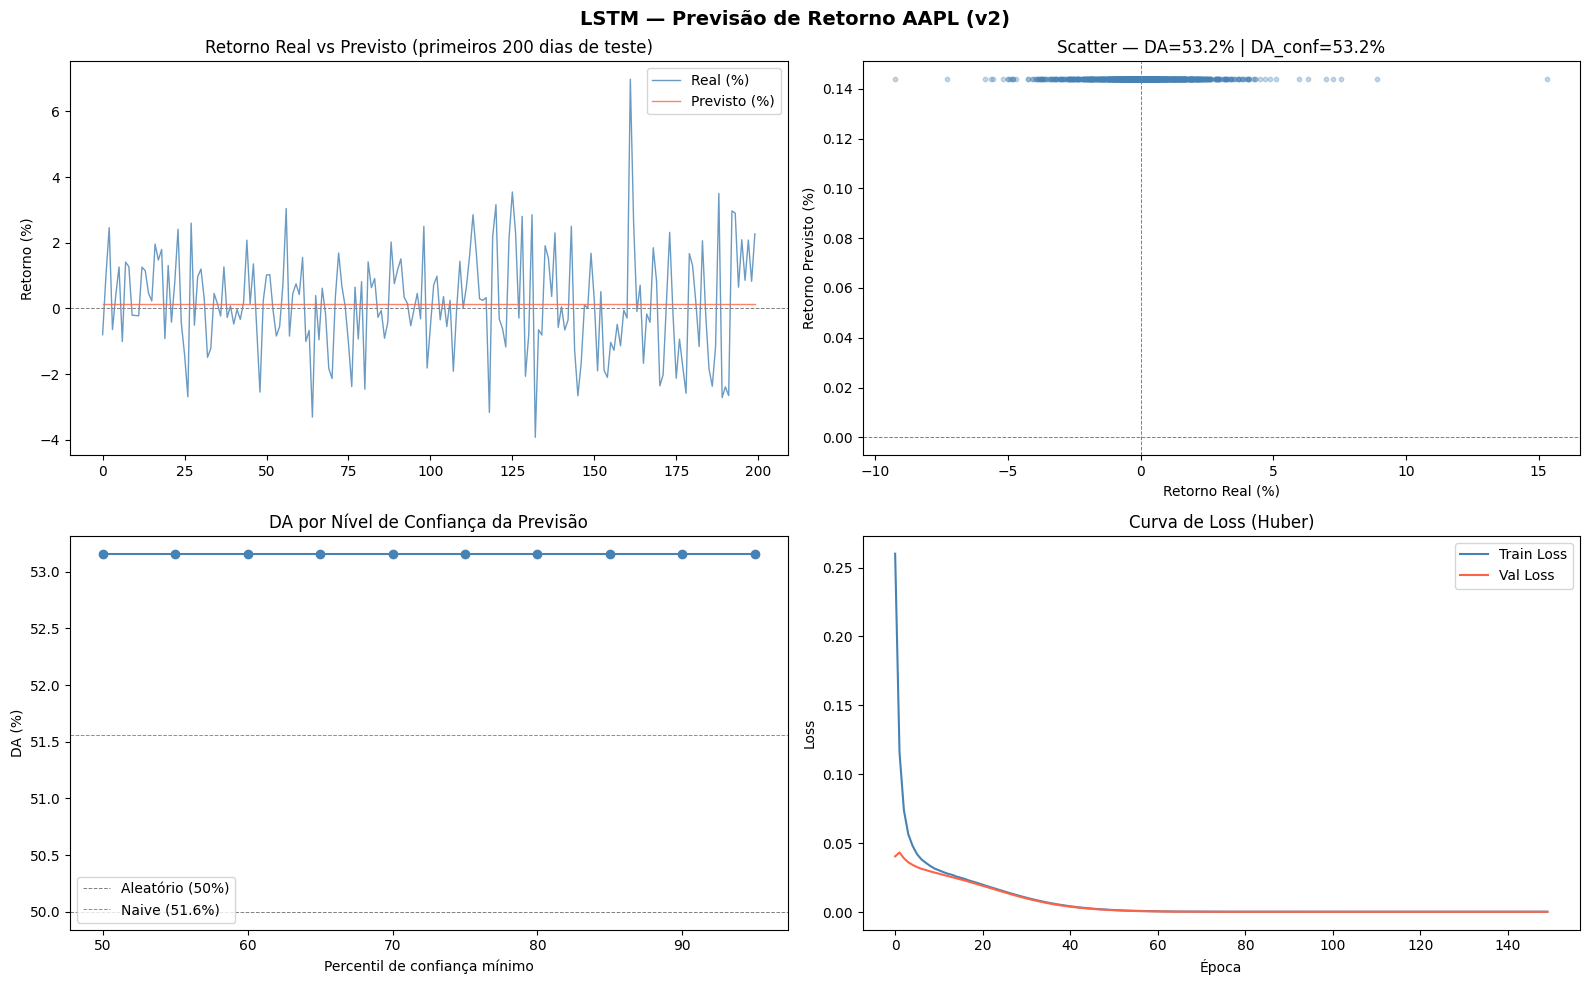

Gráfico salvo em lstm_v2_results.png


In [166]:
# =========================
# 9. VISUALIZAÇÕES
# =========================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Retorno real vs previsto
ax = axes[0, 0]
ax.plot(y_real[:200] * 100,  label="Real (%)",    color="steelblue", alpha=0.8, linewidth=1)
ax.plot(y_pred[:200] * 100,  label="Previsto (%)", color="tomato",   alpha=0.8, linewidth=1)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
ax.set_title("Retorno Real vs Previsto (primeiros 200 dias de teste)")
ax.set_ylabel("Retorno (%)")
ax.legend()

# Plot 2: Scatter real vs previsto
ax = axes[0, 1]
ax.scatter(y_real * 100, y_pred * 100, alpha=0.3, s=10, color="steelblue")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.7)
ax.set_xlabel("Retorno Real (%)")
ax.set_ylabel("Retorno Previsto (%)")
ax.set_title(f"Scatter — DA={da:.1f}% | DA_conf={da_conf:.1f}%")

# Plot 3: DA por nível de confiança
ax = axes[1, 0]
percentiles = range(50, 96, 5)
da_by_conf  = []
for p in percentiles:
    threshold = np.percentile(conf, p)
    m = conf >= threshold
    if m.sum() > 10:
        da_by_conf.append(np.mean(np.sign(y_real[m]) == np.sign(y_pred[m])) * 100)
    else:
        da_by_conf.append(np.nan)
ax.plot(list(percentiles), da_by_conf, marker="o", color="steelblue")
ax.axhline(50, color="gray", linestyle="--", linewidth=0.7, label="Aleatório (50%)")
ax.axhline(da_naive, color="tomato", linestyle="--", linewidth=0.7, label=f"Naive ({da_naive:.1f}%)")
ax.set_xlabel("Percentil de confiança mínimo")
ax.set_ylabel("DA (%)")
ax.set_title("DA por Nível de Confiança da Previsão")
ax.legend()

# Plot 4: Loss curves
ax = axes[1, 1]
ax.plot(history.history["loss"],     label="Train Loss", color="steelblue")
ax.plot(history.history["val_loss"], label="Val Loss",   color="tomato")
ax.set_title("Curva de Loss (Huber)")
ax.set_ylabel("Loss")
ax.set_xlabel("Época")
ax.legend()

plt.suptitle("LSTM — Previsão de Retorno AAPL (v2)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("Gráfico salvo em lstm_v2_results.png")